In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [56]:
df = pd.read_csv("/FastHome/gyula/designs/place_holder/DATA/gy_2nd_iter_try_41_more_iter/md_sim_analysis/mmpbsa/mmpbsa_per_replicate.csv")

In [57]:
df_rep1 = df.loc[df.rep == "rep_1",]
df_rep2 =df.loc[df.rep == "rep_2",]
df_rep3 = df.loc[df.rep == "rep_3",]
df_rep4 =df.loc[df.rep == "rep_4",]
df_rep5 =df.loc[df.rep == "rep_5",]

In [31]:
df

,subdir,job,rep,delta_total,dG_binding_IE,dG_binding_IE_err
0,job_1/rep_1,job_1,rep_1,-66.04,-19.67,5.47
1,job_1/rep_2,job_1,rep_2,-71.17,-26.97,7.01
2,job_1/rep_3,job_1,rep_3,-71.09,-37.97,5.90
3,job_1/rep_4,job_1,rep_4,-67.96,-33.14,6.36
4,job_1/rep_5,job_1,rep_5,-64.98,-16.61,5.73
...,...,...,...,...,...,...
377,job_96/rep_1,job_96,rep_1,-91.66,-59.79,7.64
378,job_96/rep_2,job_96,rep_2,-87.72,-35.47,20.06
379,job_96/rep_3,job_96,rep_3,-83.63,-38.13,8.54
380,job_96/rep_4,job_96,rep_4,-72.94,-27.52,7.00


In [59]:
df_rep4.shape
cut =65

[[1.         0.66776959]
 [0.66776959 1.        ]]


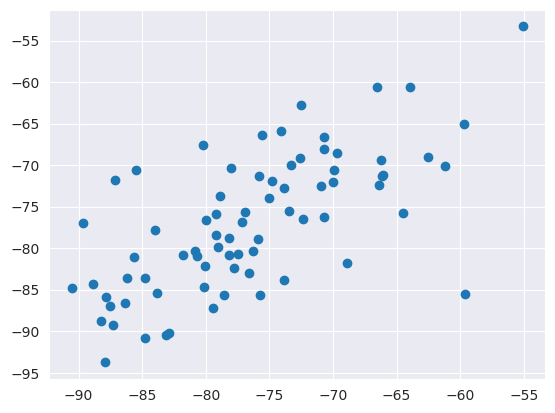

In [51]:
plt.scatter(x = df_rep1.delta_total[0:cut], y= df_rep2.delta_total[0:cut])
print(np.corrcoef(x = df_rep1.delta_total[0:cut], y= df_rep2.delta_total[0:cut]))

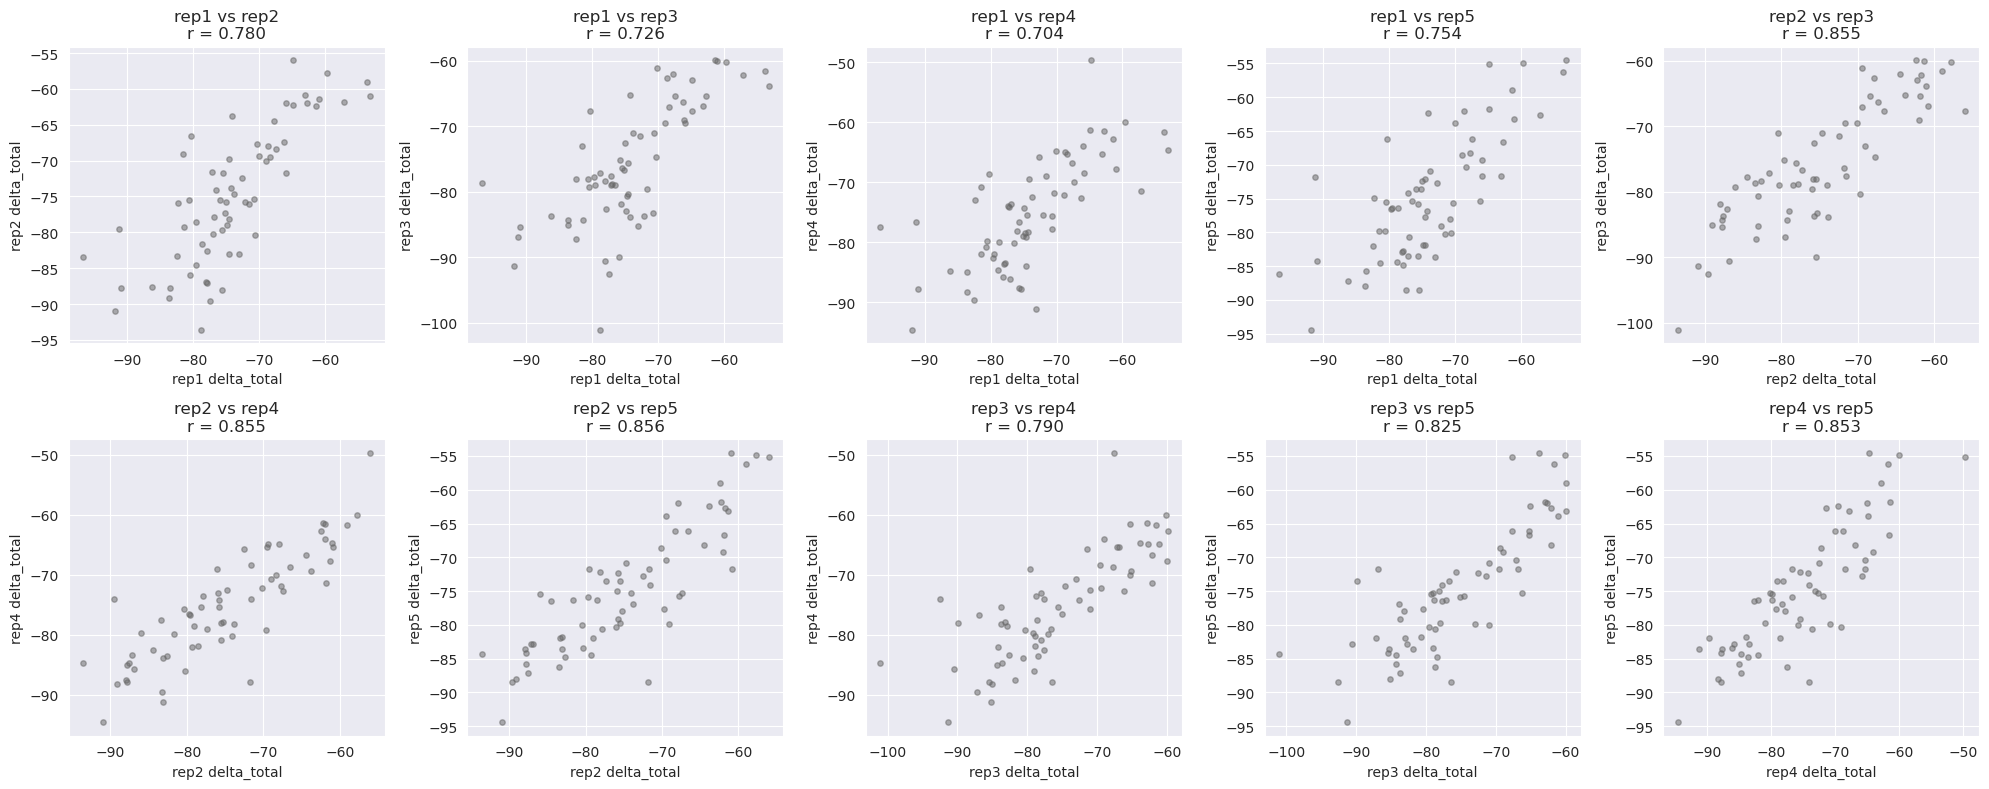

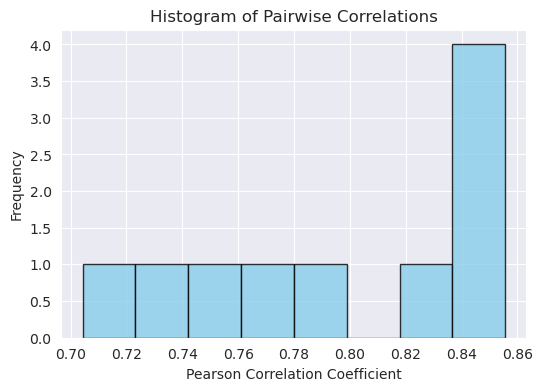

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Assuming df_rep1, df_rep2, df_rep3, df_rep4, df_rep5 and 'cut' are defined in your environment
reps = [df_rep1, df_rep2, df_rep3, df_rep4, df_rep5]
labels = ['rep1', 'rep2', 'rep3', 'rep4', 'rep5']

correlations = []
combinations = list(itertools.combinations(range(5), 2))

# 1. Plot all pairwise scatters (2 rows, 5 columns for 10 pairs)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for idx, (i, j) in enumerate(combinations):
    x = reps[i].delta_total[0:cut]
    y = reps[j].delta_total[0:cut]

    # Scatter plot
    axes[idx].scatter(x, y, alpha=0.5, color="#666666", s=15)
    axes[idx].set_xlabel(f'{labels[i]} delta_total')
    axes[idx].set_ylabel(f'{labels[j]} delta_total')

    # Correlation calculation
    corr = np.corrcoef(x, y)[0, 1]
    correlations.append(corr)

    # Add correlation to the subplot title
    axes[idx].set_title(f'{labels[i]} vs {labels[j]}\nr = {corr:.3f}')

plt.tight_layout()
plt.show()

# 2. Plot histogram of the 10 pairwise correlation coefficients
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=8, edgecolor='black', color='skyblue', alpha=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Frequency')
plt.title('Histogram of Pairwise Correlations')
plt.show()